In [ ]:
# Always run this code.
%config InteractiveShell.ast_node_interactivity="none"
import sys
if 'google.colab' in sys.modules:
  !pip install --force-reinstall git+https://github.com/jamcoders/jamcoders-public-2026.git --quiet
from jamcoders.base_utils import *
from jamcoders.week4.labw4d2a import *
import matplotlib.pyplot as plt
import numpy as np
import random

# Week 4, Day 2A: NGrams

## Question 1: Analyzing a Text Dataset

Run the next cell to load the [DailyDialog](https://paperswithcode.com/dataset/dailydialog) dataset, which contains a collection of conversations. Special symbols `<START>` and `<END>` represent the beginning of a sequence and end of a sequence, respectively.

In [ ]:
dataset = load_dataset()

Run the following cell to get an idea of what the dataset looks like.

In [ ]:
print(dataset[:50])

['<START>', 'how', 'does', 'it', 'fit', 'it', 'fits', 'fine', "i'll", 'take', 'it', 'how', 'much', 'is', 'it', '<END>', '<START>', 'look', 'i', 'bought', 'these', 'shoes', 'only', 'three', 'weeks', 'ago', 'and', 'there', 'is', 'a', 'hole', 'in', 'them', 'already', 'if', 'that', 'happen', 'to', 'me', "i'll", 'take', 'them', 'back', 'to', 'the', 'shop', '<END>', '<START>', 'i', 'have']


**1.1**

Follow the following pseudocode to print the first 5 sequences:

1. Initialize `end_count` to 0. This will represent the number of `<END>` words encountered in the dataset.
2. Initialize `i` to 0. This will represent the index into the dataset.
3. While `end_count < 5`, do the following:
   1. Let `word` be `dataset[i]`.
   2. If `word` is not `"<END>"` and not `"<START>"`, then:
        - Print `word` followed by a space (on the same line).
   3. Else if `word` is `"<END>"`, then:
      - Increment `end_count` by 1.
      - Print a newline to start a new sequence.
   4. Increment `i` by 1.

**HINT:** `print("Hello", end=" ")` prints `"Hello "` without moving to a new line. Calling `print()` prints a new line but nothing else.

Your output should looks like this:
```
how does it fit it fits fine i'll take it how much is it
look i bought these shoes only three weeks ago and there is a hole in them already if that happen to me i'll take them back to the shop
i have a little problem with room 507 problems are what we're here for sir please tell me your problem
how would you like to send it by airmail
you need to fill out this form please all i want is the same thing on this card
```

In [ ]:
# YOUR CODE HERE

how does it fit it fits fine i'll take it how much is it 
look i bought these shoes only three weeks ago and there is a hole in them already if that happen to me i'll take them back to the shop 
i have a little problem with room 507 problems are what we're here for sir please tell me your problem 
how would you like to send it by airmail 
you need to fill out this form please all i want is the same thing on this card 


**1.2**

Implement the function `get_word_counts`, which takes in a list of strings and assigns `word_counts` to a dictionary which maps each word to the number of times it appears in a list.

In [ ]:
def get_word_counts(lst):
    """
    Counts the occurrences of each word in the input list.

    Args:
        lst (list[str]): An list of words.

    Returns:
        dict: A dictionary mapping each word to the number of times it appears in lst.
    """
    # YOUR CODE HERE

In [ ]:
# Verify that your implementation passes ALL of these tests before moving on
fruit_lst = ['apple', 'banana', 'apple', 'cherry', 'banana', 'cherry', 'cherry', 'apple', 'cherry', 'cherry']
fruit_counts = get_word_counts(fruit_lst)
expected_counts = {'apple': 3, 'banana': 2, 'cherry': 5}
assert_equal(got=fruit_counts, want=expected_counts)

empty_lst = []
empty_counts = get_word_counts(empty_lst)
assert_equal(got=empty_counts, want={})

single_word_lst = ['only'] * 7
single_counts = get_word_counts(single_word_lst)
assert_equal(got=single_counts, want={'only': 7})

Test case passed.
Test case passed.
Test case passed.


Now, run the following cells to initialize a dictionary called `word_counts` that maps words to counts for the entire dataset. Check out the word counts of the following words!

In [ ]:
word_counts = get_word_counts(dataset)

In [ ]:
print(word_counts['i'])

71927


In [ ]:
print(word_counts['love'])

1592


In [ ]:
print(word_counts['math'])

86


**1.3**

Run the cell below to visualize the 15 most common words in the dataset and their frequencies.

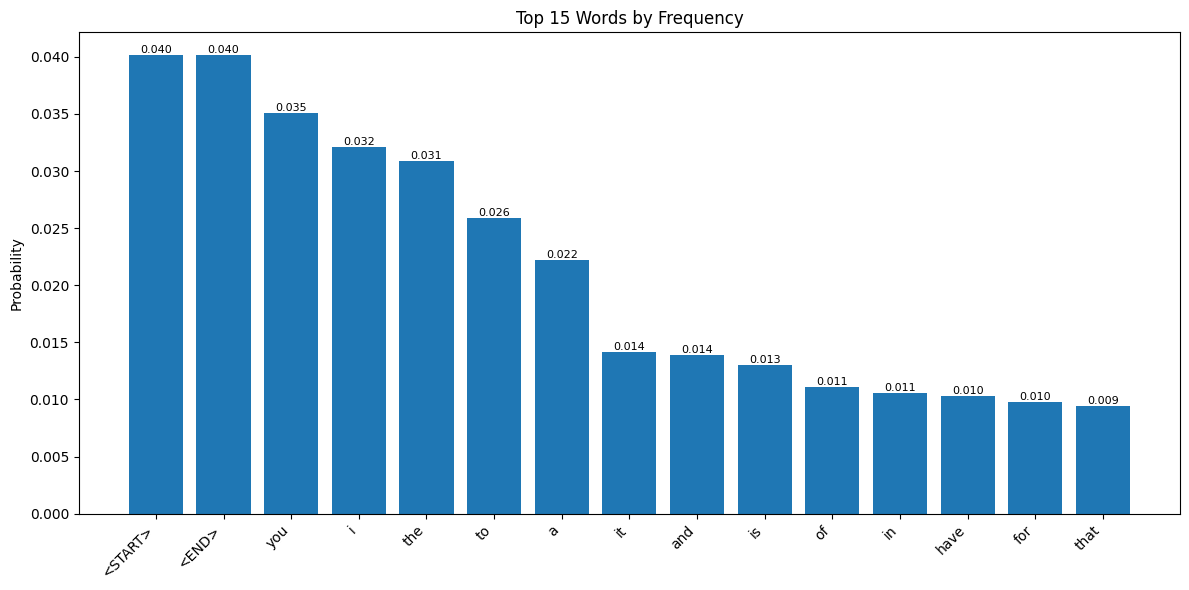

In [ ]:
visualize_barplot(word_counts, top_n=15)

What does this chart suggest about how language is distributed in the dataset? Answer in 1-2 sentences. This is an open-ended question -- there is no single correct answer!

_Type your answer here, replacing this text._

**1.4**

Write a function called `cumulative_sum` which takes in a list of numbers and returns a new list where the i-th element is the sum of the first i + 1 elements from the input list.

For example,`cumulative_sum([1, 3, 5])` would return `[1, 1 + 3, 1 + 3 + 5] --> [1, 4, 9]`.

In [ ]:
def cumulative_sum(lst):
    """
    Returns the cumulative sum of a list of numbers.

    Parameters:
        lst (list): A list of numbers sorted in non-decreasing order.

    Returns:
        list: A new list where the i-th element is the sum of the first i+1 elements of the input list.
    """
    # YOUR CODE HERE

In [ ]:
# Verify that your implementation passes ALL of these tests before moving on
a = [1, 3, 5]
assert_equal(got=cumulative_sum(a), want=[1, 4, 9])
assert_equal(got=a, want=[1, 3, 5]) # This should stay the same

assert_equal(got=cumulative_sum([]), want=[])
assert_equal(got=cumulative_sum([5]), want=[5])
assert_equal(got=cumulative_sum([0, 0, 0]), want=[0, 0, 0])
assert_equal(got=cumulative_sum([-3, -2, -1]), want=[-3, -5, -6])
assert_equal(got=cumulative_sum([-2, 0, 3]), want=[-2, -2, 1])
assert_equal(got=cumulative_sum([2, 2, 2, 2]), want=[2, 4, 6, 8])

Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.


**1.5**

Run the code below to generate a CDF (Cumulative Distribution Function) plot. This plot uses your `cumulative_sum` function to show how the most common words add up to make a larger and larger share of the dataset.

- The **x-axis** shows words in order from most to least frequent.  
- The **y-axis** shows the cumulative percentage of all word occurrences counted so far.

**For example:**
- At **x = 1**, the CDF shows what percent of all words are just the single most frequent word.
- At **x = 10**, it shows the percent made up by the 10 most common words.
- The line rises as you go right, eventually reaching **100%** once all words are included.

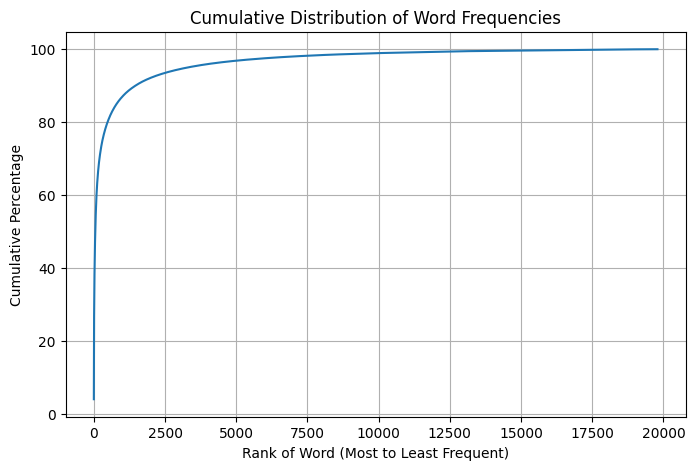

In [ ]:
sorted_word_counts = sorted(word_counts.values(), reverse=True)
cumulative_percent_of_words = 100 * np.array(cumulative_sum(sorted_word_counts)) / sum(sorted_word_counts)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_percent_of_words)
plt.xlabel("Rank of Word (Most to Least Frequent)")
plt.ylabel("Cumulative Percentage")
plt.title("Cumulative Distribution of Word Frequencies")
plt.grid(True)
plt.show()

Use the CDF plot to answer the questions below.

Approximately how many unique words are in the dataset? A rough answer is fine, no need to be exact.

In [ ]:
num_unique_words = ...

Roughly what percentage of all words in the dataset are accounted for by the 2,500 most frequent words? Your answer should be a percentage between 0 and 100. A rough answer is fine, no need to be exact.

In [ ]:
percent_covered_by_2500 = ...

Run the below code to check your answers. Do not move on until they are both correct. Feel free to call over a TA if you need help!

In [ ]:
check_answer_1_6([num_unique_words, percent_covered_by_2500])

**1.6**

Run the cell below to make a cool visualization!

In [ ]:
plot_wordcloud(word_counts)

## Question 2: Unigram Language Model

In this section, we will make a unigram language model.

**2.1**

Complete the `probability` function, which takes a `word` and and a dictionary `word_counts`, and returns the probability of that word occuring. The probability of a word in a dataset tells you how often you’d expect to see that word if you randomly picked one word from the text. If the word is not found in the dictionary, its count is assumed to be 0.

**HINT:** using Python's build in `sum` function on the values of `word_counts` (i.e. `sum(word_counts.values())`) is one way to get the total number of words in the dataset.

**HINT:** if you are confused about how to get started, check out the test cases in the cell below!

In [ ]:
def probability(word, word_counts):
    """
    Compute the probability of a word being sampled from the dataset.
    This represents how likely you are to encounter that word if you
    randomly select a single word from the text.

    This function takes a word and a dictionary of word counts,
    and returns the probability of that word occurring. If the word
    is not found in the dictionary, its count is assumed to be 0.

    Parameters:
        word (str): The word whose probability we want to compute.
        word_counts (dict): A dictionary mapping each word to the
          number of times it appears.

    Returns:
        float: The probability of the word, computed as its count
               divided by the total count of all words.
    """
    # YOUR CODE HERE

In [ ]:
# Verify that your implementation passes ALL of these tests before moving on
fruit_counts = {'apple': 3, 'banana': 2, 'cherry': 5}

assert_equal(got=probability('apple', fruit_counts), want=3 / 10)
assert_equal(got=probability('banana', fruit_counts), want=2 / 10)
assert_equal(got=probability('cherry', fruit_counts), want=5 / 10)
assert_equal(got=probability('date', fruit_counts), want=0.0)

assert_equal(got=probability('', {'': 1, 'other': 1}), want=0.5)
assert_equal(got=probability('only', {'only': 7}), want=1.0)

assert_equal(got=probability('i', word_counts), want=0.03212862707261292)
assert_equal(got=probability('love', word_counts), want=0.0007111206403659234)
assert_equal(got=probability('math', word_counts), want=3.8414808461978273e-05)

Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.


**2.2**

Write a function called `get_word_probabilities` which returns a dictionary that maps each word in `word_counts` to the probability that a given word in the dataset is that word.

**HINT:** if you are confused about how to get started, check out the test cases in the cell below!

In [ ]:
def get_word_probabilities(word_counts):
    """
    Computes the probability of each word in the dataset appearing as the next word.

    Parameters:
        word_counts (dict): A dictionary mapping words to their counts in the dataset.

    Returns:
        dict: A dictionary mapping each word to its probability based on its frequency in word_counts.
    """
    # YOUR CODE HERE

In [ ]:
# Verify that your implementation passes ALL of these tests before moving on
fruit_counts = {'apple': 3, 'banana': 2, 'cherry': 5}
fruit_probs = get_word_probabilities(fruit_counts)
assert_equal(len(fruit_probs), 3)
assert_equal(got=fruit_probs['apple'], want=3 / 10)
assert_equal(got=fruit_probs['banana'], want=2 / 10)
assert_equal(got=fruit_probs['cherry'], want=5 / 10)

empty_counts = {'': 1, 'other': 1}
probs = get_word_probabilities(empty_counts)
assert_equal(got=len(probs), want=2)
assert_equal(got=probs[''], want=0.5)
assert_equal(got=probs['other'], want=0.5)

single_word_counts = {'only': 7}
probs = get_word_probabilities(single_word_counts)
assert_equal(got=len(probs), want=1)
assert_equal(got=probs['only'], want=1.0)

Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.
Test case passed.


The below cell generates a dictionary mapping words in `dataset` to its probability, and performs a few sanity checks.

In [ ]:
# Verify that your implementation passes ALL of these tests before moving on
word_probabilities = get_word_probabilities(word_counts)

assert_equal(got=sum(word_probabilities.values()), want=1.0)
assert_equal(got=len(word_probabilities), want=19790)

Test case passed.
Test case passed.


**2.3**

Here we'll implement the logic to run the chatbot. To help you, we've implemented some functions. You should NOT edit these functions, and you don't need to understand how they work; just what arguments they take and return.

`generate_unigram_response`

- Generates text using a unigram language model when given `word_probabilities`, a dictionary mapping words to their probabilities.
- `max_length` can is the maximum length of the chatbot response. If the user does not specify the `max_length`, it defaults to 15.

`run_unigam_chatbot`

* Continuously prompts the user for input and generates a response using `generate_unigram_response` until the user types 'quit'.

In [ ]:
def generate_unigram_response(word_probabilities, max_length=15):
    """
    Generates a sequence of words using a unigram language model.

    Each word is sampled independently based on its probability, ignoring previous context.
    The generation stops when the maximum number of words is reached or when the <END>
    (end of sentence) is sampled.

    Parameters:
        word_probabilities (dict): A dictionary mapping words to their unigram probabilities.
        max_length (int): The maximum number of words to generate (default is 15).

    Returns:
        str: A generated string formed by joining the sampled words, with basic formatting applied
            to remove special words like <START> and <END>.
    """

    response_words = []
    for _ in range(max_length):
        words = list(word_probabilities.keys())
        probabilities = list(word_probabilities.values())
        word = random.choices(words, weights=probabilities)[0]

        response_words.append(word)

        if word ==  '<END>':
            break

    response = ' '.join(response_words).replace(' <START>', '').replace(' .', '.').replace(" '", "'").replace('<END>', '')
    return response.strip()

def run_unigram_chatbot():
    """
    Starts an interactive loop for chatting with a simple unigram-based chatbot.

    The chatbot generates responses by sampling words independently from a unigram language model.
    The conversation continues until the user types 'quit'.
    """
    print("Hello! I'm a simple chatbot. Let's chat!")
    print("(Type 'quit' to end the conversation)\n")

    while True:
        user_input = input("\nYou: ")

        if user_input.lower() == 'quit':
            print("Chatbot: Goodbye! Thanks for chatting!")
            return

        if not user_input.strip():
            print("Chatbot: I'm listening...") # Re-prompt when given empty input
            continue

        response = generate_unigram_response(word_probabilities)

        print(f"Chatbot: ", response, "\n")

Run the cell below to interact with the chatbot!

In [ ]:
run_unigram_chatbot()

Hello! I'm a simple chatbot. Let's chat!
(Type 'quit' to end the conversation)



**2.4**

Answer the following questions in 2-3 sentences total. Why is the unigram model not making real sense? What does our model assume the way humans speak? Why is that not a very good assumption?

_Type your answer here, replacing this text._

## Question 3: NGram Model

Let’s say you’re trying to predict what word comes next in a sentence.

You see:

> *see you  ___________*

What could the next word be? Some possibilities:

- **soon** → *see you soon*
- **later** → *see you later*
- **again** → *see you again*
- **never** → *see you never*

These all make sense, but they mean different things. NGrams give us a way to use the context of the preceding words to quantify the most likely next word.

If someone says:

> *Thanks for visiting! See you ___________*

You’ll probably hear:

> **soon** or **later**

But if the sentence is:

> *After what you did… see you ___________*

You might hear:

> **never**

The meaning of the sentence, and what word comes next, depends on the **context**, or the **words that came before**.


**3.1**

Consider the Python dictionary `trigram_counts_example`. Each key is a tuple of two words (a 2-word context), and the value is a dictionary of possible third words and how many times they each were seen in the dataset.

**Note**: a tuple is like a list, but you can't change it after it's created, and it uses parentheses instead of square brackets. For reasons outside the scope of JamCoders, tuples can be used as keys in dictionaries, but lists cannot. Ask a TA if you are interested in why!

In [ ]:
trigram_counts_example = {
    ("i", "love"): {"you": 3, "dogs": 2},
    ("love", "you"): {"too": 1, "so": 1},
    ("you", "too"): {"<END>": 1},
    ("you", "so"): {"much": 1},
    ("so", "much"): {"<END>": 1},
    ("i", "have"): {"dogs": 2},
    ("have", "dogs"): {"<END>": 2},
}

Answer the following questions below.

Assign the the variable `i_love` to a list of the possible next words after the phrase "i love".


In [ ]:
i_love = ...

Based on the counts for ("i", "love"), what is the probability of seeing the word "dogs" next? Assign this variable to `prob`. Your answer should be a float between 0 and 1.

In [ ]:
prob = ...

Given the context "i love", what is the most likely next word? Assign this word to `most_likely`

In [ ]:
most_likely = ...

Suppose you start with the words ["i", "love"]. Using `trigram_counts`, what is a possible 5-word sentence you could build?  Assign `sentence` to a list containing these 5 words. Your answer should not include any capital letters or punctuation.

In [ ]:
sentence = ...

Run the below code to check your answers. Do not move on until they are both correct. Feel free to call over a TA if you need help!

In [ ]:
check_answer_3_1([i_love, prob, most_likely, sentence])

**3.2**

Below you will find an implementation of an NGram Chatbot. You do not need to code anything in this problem. You can just run the cells in order until you reach the last cell, which allows you to run the chatbot. Along the way, respond the to written questions.

We provide a description of each function below for your interest.

`build_ngram_counts`
- Generates a dictionary of NGram Counts. Given argument `n`, Each key is a tuple of (n-1) words, and the value is a dictionary of possible nth words and how many times they each were seen in the dataset.

`get_context`
- Get the last n-1 words from text_prefix to use as context for n-gram prediction. If there aren't enough words, pad with `<START>` words at the beginning.

`generate_ngram_response`

- Generates text using an NGram language model (no context between words) when given `ngram_counts`, a dictionary mapping NGram tuples to their counts.
- `max_length` can is the maximum length of the chatbot response. If the user does not specify the `max_length`, it defaults to 15.

`run_ngram_chatbot`

* Continuously prompts the user for input and generates a response using `generate_unigram_response` until the user types  'quit'.


In [ ]:
def build_ngram_counts(lst, n):
    """
    Build N-gram counts from a list of words, with <START> padding at the start.

    If <START> appears in the context, all words before the last <START> are replaced with <START>.

    Args:
        list (list): List of words including <END> markers
        n (int): Size of n-grams (2 for bigrams, 3 for trigrams, etc.)

    Returns:
        dict: Nested dictionary {context: {next_word: count}}
              where context is tuple of n-1 words
    """
    ngram_counts = {}

    for i in range(len(dataset) - n + 1):
        ngram = tuple(dataset[i:i + n])
        context = list(ngram[:-1])
        next_word = ngram[-1]

        if '<START>' in context:
            last_bos_index = len(context) - 1 - context[::-1].index('<START>')
            context[:last_bos_index] = ['<START>'] * last_bos_index

        context = tuple(context)

        if context not in ngram_counts:
            ngram_counts[context] = {}

        if next_word in ngram_counts[context]:
            ngram_counts[context][next_word] += 1
        else:
            ngram_counts[context][next_word] = 1

    return ngram_counts

Run the following cells to generate `bigram_counts` and `trigram_counts`, respectively

In [ ]:
bigram_counts = build_ngram_counts(dataset, 2)
trigram_counts = build_ngram_counts(dataset, 3)

Observe the following example use cases of `bigram_counts` and `trigram_counts`.

In [ ]:
print(bigram_counts.keys())

In [ ]:
print(bigram_counts[("i",)])

In [ ]:
print(bigram_counts[("love",)])

In [ ]:
print(bigram_counts[("you",)])

In [ ]:
print(trigram_counts[("i", "love",)])

In [ ]:
print(trigram_counts[("go", "to",)])

What kind of information do these counts capture? How might they be more useful than a unigram in writing a program that generates or analyzes text?

_Type your answer here, replacing this text._

In [ ]:
def get_context(prompt, n):
    """
    Get the last n-1 words from prompt to use as context for n-gram prediction.
    If there aren't enough words, pad with <START> words at the beginning.

    Args:
        prompt (str): Input text (str)
        n (int): Size of NGram (2 for bigrams, 3 for trigrams, etc.)

    Returns:
        tuple: Last n-1 words as a tuple (context for next word prediction)
               Padded with <START> words if not enough words available
    """
    words = clean(prompt).split()

    context_words = words[-(n-1):] if len(words) >= n-1 else words

    needed_padding = (n - 1) - len(context_words)
    if needed_padding > 0:
        context_words = ['<START>'] * needed_padding + context_words

    context = tuple(context_words)
    return context

In [ ]:
def generate_ngram_response(prompt, ngram_counts, n, max_length=15):
    """Generate a response using an n-gram language model."""

    response_words = list(get_context(prompt, n=n))

    # Caching a fallback of sampling a random word from all available next words in ngram_counts
    all_words = []
    all_weights = []
    for counts in ngram_counts.values():
        for word, count in counts.items():
            all_words.append(word)
            all_weights.append(count)

    for _ in range(max_length):
        current_context = tuple(response_words[-(n-1):])

        possible_next_words = []
        weights = []

        for ngram, counts in ngram_counts.items():
            if ngram == current_context:
                for word, count in counts.items():
                    possible_next_words.append(word)
                    weights.append(count)

        if len(possible_next_words) == 0:
            next_word = random.choices(all_words, weights=all_weights)[0]
        else:
            next_word = random.choices(possible_next_words, weights=weights)[0]

        response_words.append(next_word)

        if next_word == '<END>':
            break

    final_words = response_words[(n-1):]
    response = ' '.join(final_words).replace('<END>', '').replace(' .', '.').replace(" '", "'").replace('<START>', '')
    return response.strip()

In [ ]:
def run_ngram_chatbot(word_counts, n):
    """
    Generate a text response using an n-gram language model.

    Given a prompt and an n-gram frequency dictionary, this function continues the text
    by repeatedly sampling the next word based on the previous (n-1) words. The response
    generation stops either after reaching max_length words or when the <END> is produced.

    Args:
        prompt (str): The starting text to build the response from.
        ngram_counts (dict): A dictionary where keys are (n-1)-tuples of words and values
                             are dictionaries mapping possible next words to their counts.
        n (int): The 'n' in NGram (e.g., 2 for bigrams, 3 for trigrams).
        max_length (int): The maximum number of words to generate.

    Returns:
        str: A generated text response.
    """
    print("Hello! I'm a simple chatbot. Let's chat!")
    print("(Type 'quit' to end the conversation)\n")

    while True:
        user_input = input("\nYou: ")

        if user_input.lower() == 'quit':
            print("Chatbot: Goodbye! Thanks for chatting!")
            return

        if not user_input.strip():
            print("Chatbot: I'm listening...") # If there is an empty input, re-prompt
            continue

        response = generate_ngram_response(user_input, word_counts, n)

        print(f"Chatbot: ", response, "\n")

Run the cell below to interact with the chatbot!

In [ ]:
run_ngram_chatbot(trigram_counts, 3)